# Parameter Fraction Analysis

Analyzes the effect of computing the Jacobian w.r.t. a random subset of parameters
on SVD optimizer performance across all datasets. At each step, a random `param_fraction`
of parameters is selected and only those columns of the Jacobian are computed (coordinate-descent style).

## 1. Setup & Data Loading

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from style import set_style, lr_labels
set_style()

PLOT_DIR = Path('plots/paramfrac')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/analysis/plots/paramfrac


In [2]:
# Load results
from style import load_results

SCAN_CONFIGS = {
    #'MNIST (LabelReg)':    'mnist_paramfrac_labelreg_scan',
    'Toy 1D':              'toy_1d_paramfrac_scan',
    'Polynomial':          'polynomial_paramfrac_scan',
}

datasets = {}
for name, scan_name in SCAN_CONFIGS.items():
    try:
        df = load_results(scan_name)
        datasets[name] = df
    except FileNotFoundError:
        print(f"  [skip] {name}: not found")

print(f"\nLoaded {len(datasets)} datasets: {list(datasets.keys())}")


Loaded 352 runs from ../experiment_results/toy_1d_paramfrac_scan/ (directory format)
Loaded 370 runs from ../experiment_results/polynomial_paramfrac_scan/ (directory format)

Loaded 2 datasets: ['Toy 1D', 'Polynomial']


In [4]:
# Helper functions
def get_loss_curve(row, loss_type='val'):
    return np.array(row['losses'][loss_type])

def get_acc_curve(row, acc_type='val_acc'):
    return np.array(row['losses'].get(acc_type, []))

def sliding_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

def add_derived_columns(df):
    df = df.copy()
    df['final_val_loss'] = df.apply(lambda r: r['losses']['val'][-1], axis=1)
    df['final_train_loss'] = df.apply(lambda r: r['losses']['train'][-1], axis=1)
    df['final_val_acc'] = df.apply(lambda r: r['losses'].get('val_acc', [np.nan])[-1], axis=1)
    df['final_train_acc'] = df.apply(lambda r: r['losses'].get('train_acc', [np.nan])[-1], axis=1)
    df['total_time'] = df['losses'].apply(lambda l: l.get('total_time', np.nan))
    df['avg_batch_time_train'] = df['losses'].apply(lambda l: l.get('avg_batch_time_train', np.nan))
    # Ensure param_fraction is numeric
    df['param_fraction'] = df['param_fraction'].fillna(1.0).astype(float)
    return df

for name in datasets:
    datasets[name] = add_derived_columns(datasets[name])

for name, df in datasets.items():
    pf_vals = sorted(df['param_fraction'].unique())
    print(f"{name}: {len(df)} runs, param_fractions={pf_vals}")

Toy 1D: 352 runs, param_fractions=[0.1, 0.25, 0.5, 0.75, 1.0]
Polynomial: 370 runs, param_fractions=[0.1, 0.25, 0.5, 0.75, 1.0]


In [7]:
param_fracs = datasets['Toy 1D']['param_fraction'].unique()
model_seeds = datasets['Toy 1D']['model_seed'].unique()
k_values = datasets['Toy 1D']['k'].unique()
rtols = datasets['Toy 1D']['rtol'].unique()
print(f"Toy 1D param_fractions: {param_fracs}")
print(f"Toy 1D model_seeds: {model_seeds}")
print(f"Toy 1D k_values: {k_values}")
print(f"Toy 1D rtols: {rtols}")

Toy 1D param_fractions: [0.1  0.25 0.5  0.75 1.  ]
Toy 1D model_seeds: [1000 1001 1002 1003 1004 1005 1006 1007 1008]
Toy 1D k_values: [16 32]
Toy 1D rtols: [0.001]


# Loss curves

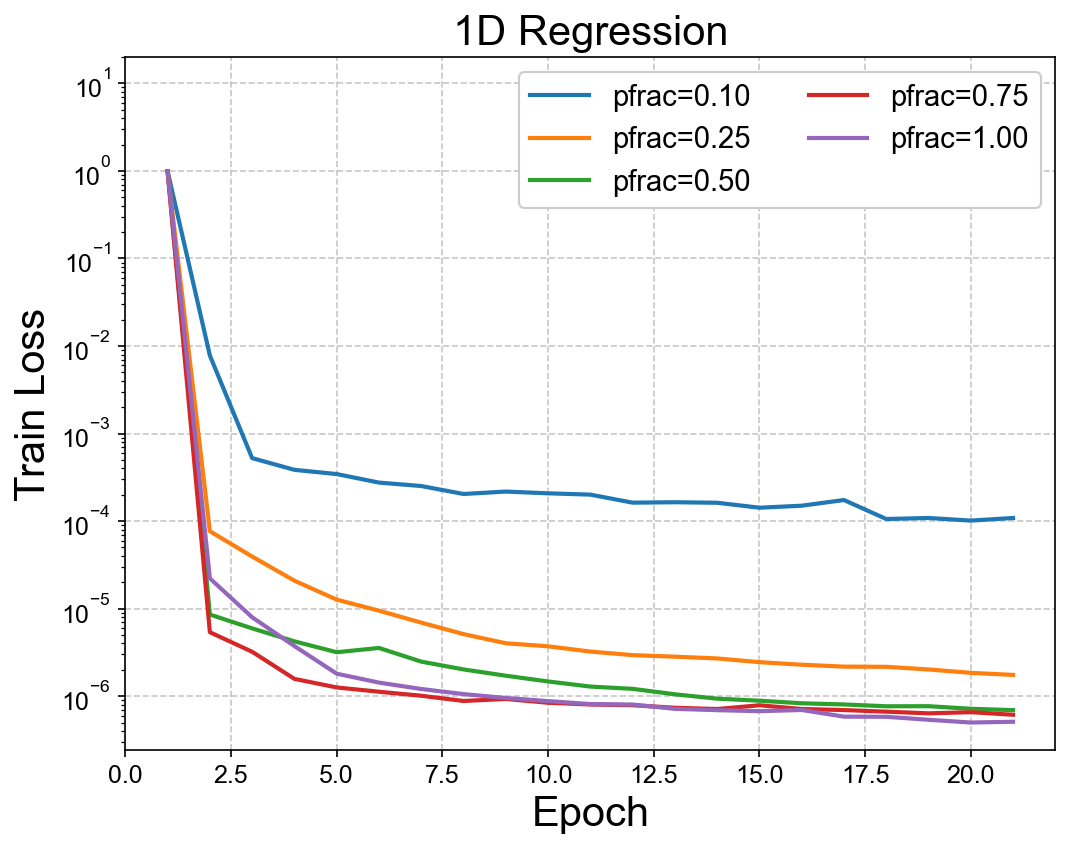

In [27]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

K_SEL = 16
RTOL = 1e-3
LR = 0.05

for pfrac in param_fracs:
    df = datasets['Toy 1D']
    losses = []
    for mseed in [model_seeds[3]]:
        cut = (df['param_fraction'] == pfrac) & (df['model_seed'] == mseed) & (df['k'] == K_SEL) & (df['rtol'] == RTOL) & (df['lr'] == LR)
        row = df.loc[cut]
        if len(row) > 1:
            print("bad!")
        row = row.iloc[0]
        losses.append(np.array(get_loss_curve(row, 'val')).reshape(1,-1))
    losses = np.concatenate(losses, axis=0)
    mean_loss = np.mean(losses, axis=0)
    std_loss = np.std(losses, axis=0)
    epochs = np.arange(1, len(mean_loss) + 1)
    ax.plot(epochs, mean_loss, label=f"pfrac={pfrac:.2f}", zorder=2)
    #ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1)
ax.set_title(f"1D Regression")
plt.ylim([None,20])
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

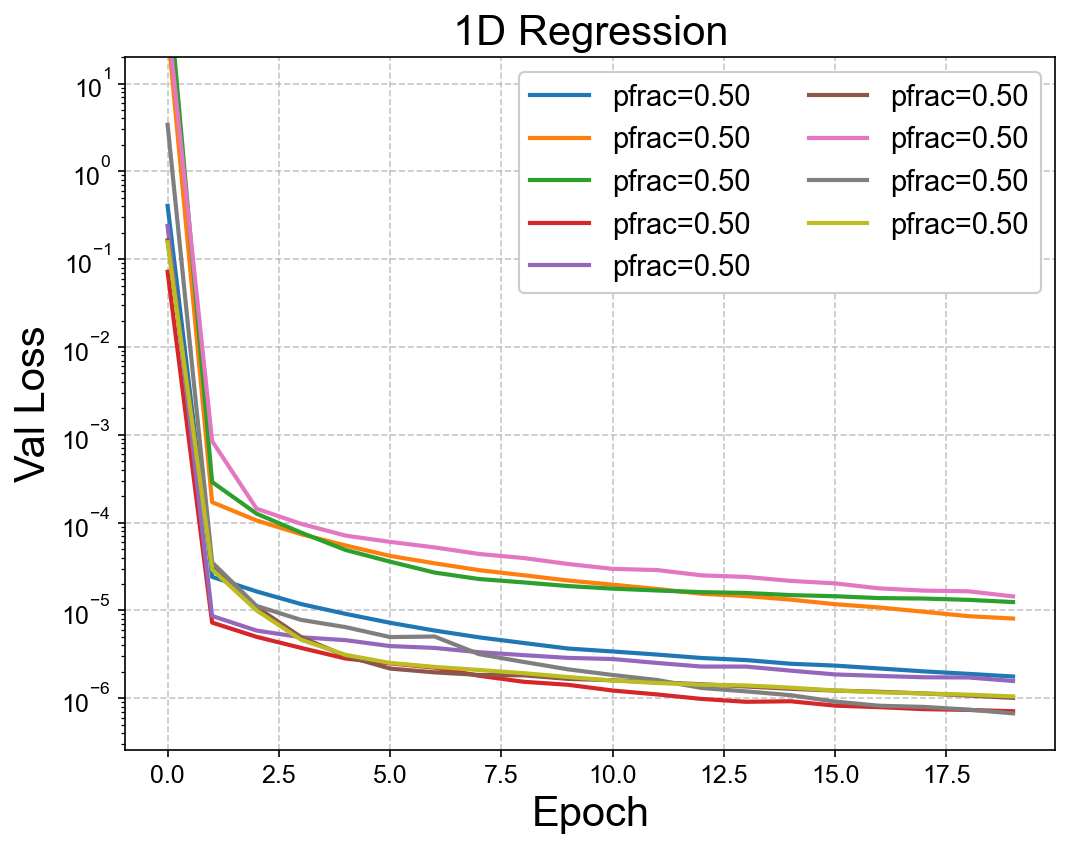

In [23]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

K_SEL = 16
RTOL = 1e-3
LR = 0.05

for pfrac in [0.5]:
    df = datasets['Toy 1D']
    losses = []
    for mseed in model_seeds:
        cut = (df['param_fraction'] == pfrac) & (df['model_seed'] == mseed) & (df['k'] == K_SEL) & (df['rtol'] == RTOL) & (df['lr'] == LR)
        row = df.loc[cut]
        if len(row) > 1:
            print("bad!")
        row = row.iloc[0]
        losses = np.array(get_loss_curve(row, 'train'))
        ax.plot(losses, label=f"pfrac={pfrac:.2f}", zorder=2)
    #ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Val Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1)
ax.set_title(f"1D Regression")
plt.ylim([None,20])
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

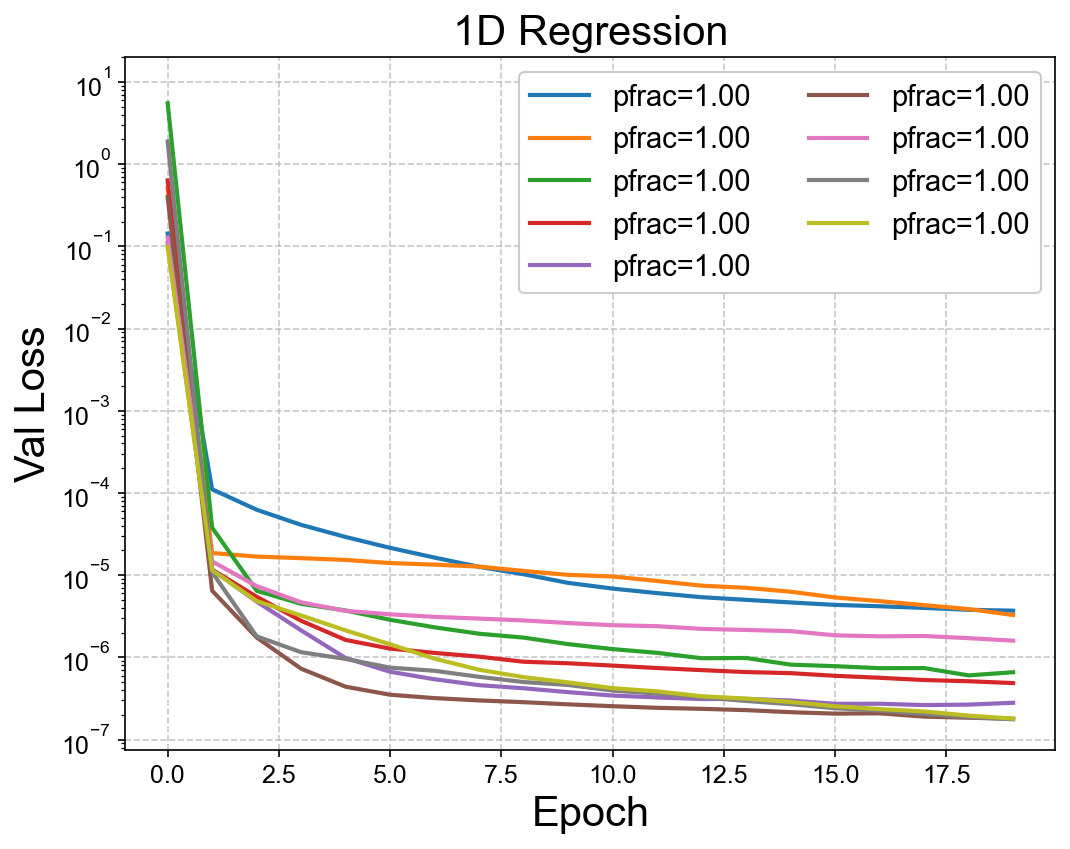

In [28]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

K_SEL = 16
RTOL = 1e-3
LR = 0.05

for pfrac in [1.0]:
    df = datasets['Toy 1D']
    losses = []
    for mseed in model_seeds:
        cut = (df['param_fraction'] == pfrac) & (df['model_seed'] == mseed) & (df['k'] == K_SEL) & (df['rtol'] == RTOL) & (df['lr'] == LR)
        row = df.loc[cut]
        if len(row) > 1:
            print("bad!")
        row = row.iloc[0]
        losses = np.array(get_loss_curve(row, 'train'))
        ax.plot(losses, label=f"pfrac={pfrac:.2f}", zorder=2)
    #ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Val Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1)
ax.set_title(f"1D Regression")
plt.ylim([None,20])
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)